<a href="https://colab.research.google.com/github/gustavolasantos-boop/CP1_SERS_ANALISE_DE_DADOS/blob/main/Desafio_Final_Energia_ONS_API_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# Desenvolva aqui o DESAFIO 1
dados = pd.DataFrame(registros)
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
dados.shape
print(f"O numero de linhas é: {dados.shape[0]}")
print(f"O numero de colunas é: {dados.shape[1]}")


O numero de linhas é: 336
O numero de colunas é: 11


In [ ]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [ ]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


### Atributos do DataFrame:

*   **Data/Hora:** `dat_referencia`, `din_referenciautc`, `din_atualizacao`
*   **Área de Carga:** `cod_areacarga`
*   **Valor de Carga:** `val_cargaglobal`, `val_cargaglobalcons`, `val_cargaglobalsmmgd`, `val_cargasupervisionada`, `val_carganaosupervisionada`, `val_cargammgd`

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
#Renomeie os principais atributos com nomes mais simples.
dados.rename(columns={
    'cod_areacarga': 'Area_Carga',
    'din_atualizacao': 'Data_Atualizacao',
    'dat_referencia': 'Data_Referencia',
    'din_referenciautc': 'Data_Hora_UTC',
    'val_cargaglobal': 'Carga_Global',
    'val_cargaglobalcons': 'Carga_Global_Consistente',
    'val_cargaglobalsmmgd': 'Carga_Global_SMMGD',
    'val_cargasupervisionada': 'Carga_Supervisionada',
    'val_carganaosupervisionada': 'Carga_Nao_Supervisionada',
    'val_cargammgd': 'Carga_MMGD',
    'val_consistencia': 'Consistencia'
}, inplace=True)
dados.head()

,Area_Carga,Data_Atualizacao,Data_Referencia,Data_Hora_UTC,Carga_Global,Carga_Global_Consistente,Carga_Global_SMMGD,Carga_Supervisionada,Carga_Nao_Supervisionada,Carga_MMGD,Consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


### Explicação dos Atributos Renomeados:

*   **Area_Carga:** Código da área de carga (e.g., 'SP' para São Paulo).
*   **Data_Atualizacao:** Data e hora da última atualização do registro.
*   **Data_Referencia:** Data de referência da medição da carga.
*   **Data_Hora_UTC:** Data e hora de referência da medição da carga em UTC (Coordinated Universal Time).
*   **Carga_Global:** Valor da carga global total.
*   **Carga_Global_Consistente:** Valor da carga global com consistência aplicada.
*   **Carga_Global_SMMGD:** Valor da carga global considerando a medição do SMMGD (Sistema de Medição de Geração Distribuída).
*   **Carga_Supervisionada:** Valor da carga supervisionada.
*   **Carga_Nao_Supervisionada:** Valor da carga não supervisionada.
*   **Carga_MMGD:** Valor da carga referente à medição de micro e minigeração distribuída.
*   **Consistencia:** Indicador de consistência dos dados.

In [ ]:
#Crie um novo DataFrame contendo apenas os atributos necessários.
df = dados.drop(columns=['Data_Atualizacao', 'Consistencia'])
df.head()

,Area_Carga,Data_Referencia,Data_Hora_UTC,Carga_Global,Carga_Global_Consistente,Carga_Global_SMMGD,Carga_Supervisionada,Carga_Nao_Supervisionada,Carga_MMGD
0,SP,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13
1,SP,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13
2,SP,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13
3,SP,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13
4,SP,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13


In [ ]:
#Verifique valores ausentes.
df.isnull().sum()


,0
Area_Carga,0
Data_Referencia,0
Data_Hora_UTC,0
Carga_Global,0
Carga_Global_Consistente,0
Carga_Global_SMMGD,0
Carga_Supervisionada,0
Carga_Nao_Supervisionada,0
Carga_MMGD,0


In [ ]:
#Verifique se a variável de carga está em formato numérico.
df['Carga_Global'].dtype


dtype('float64')

In [ ]:
#Verifique como a data/hora está representada.
df[['Data_Referencia', 'Data_Hora_UTC']].dtypes

,0
Data_Referencia,object
Data_Hora_UTC,object


### Decisões de Tratamento de Dados:

1.  **Renomeação de Colunas:** Os atributos originais da API foram renomeados para nomes mais curtos e compreensíveis (`Area_Carga`, `Data_Atualizacao`, `Data_Referencia`, `Data_Hora_UTC`, `Carga_Global`, etc.) para facilitar a análise.
2.  **Criação de Novo DataFrame `df`:** Um novo DataFrame `df` foi criado a partir de `dados`, excluindo as colunas `Data_Atualizacao` e `Consistencia`. A coluna `Data_Atualizacao` foi descartada por não ser relevante para a análise de carga e `Consistencia` foi descartada por ter valores constantes (todos zero).
3.  **Verificação de Valores Ausentes:** Foi verificado que não há valores ausentes (NaN) nas colunas do DataFrame `df`, o que significa que nenhuma imputação ou remoção de linhas é necessária neste momento.
4.  **Verificação do Tipo de Dados da Carga:** A coluna `Carga_Global` foi confirmada como sendo do tipo numérico (`float64`), o que é adequado para cálculos e análises estatísticas.
5.  **Verificação do Tipo de Dados de Data/Hora:** As colunas `Data_Referencia` e `Data_Hora_UTC` foram identificadas como `object` (string), indicando que precisarão ser convertidas para o tipo `datetime` do Pandas para permitir análises temporais e gráficos adequados.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# Desafio 3 — Indicadores da carga elétrica (Carga_Global)
carga_minima = df['Carga_Global'].min()
carga_maxima = df['Carga_Global'].max()
carga_media = df['Carga_Global'].mean()
mediana_carga = df['Carga_Global'].median()
amplitude = carga_maxima - carga_minima
qtd_medicoes = df['Carga_Global'].count()

print(f"1. Carga mínima: {carga_minima:.3f} MW")
print(f"2. Carga máxima: {carga_maxima:.3f} MW")
print(f"3. Carga média: {carga_media:.3f} MW")
print(f"4. Mediana: {mediana_carga:.3f} MW")
print(f"5. Amplitude: {amplitude:.3f} MW")
print(f"6. Quantidade total de medições: {qtd_medicoes}")

1. Carga mínima: 12139.253 MW
2. Carga máxima: 23185.312 MW
3. Carga média: 17870.829 MW
4. Mediana: 18199.128 MW
5. Amplitude: 11046.059 MW
6. Quantidade total de medições: 336


O valor máximo de carga de 23.185,31 MW está moderadamente distante da média de 17.870,83 MW e da mediana de 18.199,13 MW, refletindo uma diferença superior a 5.300 MW em relação ao centro das observações. Considerando que a amplitude total alcançou 11.046,06 MW, esse pico expressa um comportamento de ponta bem acentuado, demonstrando que a demanda dispara em horários específicos de maior consumo, embora o comportamento médio permaneça bem abaixo desse patamar na maior parte dos dias.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# Desenvolva aqui o DESAFIO 4
# Desafio 4 — Períodos de alta demanda
limiar = 0.90 * carga_maxima
df_alta_demanda = df[df['Carga_Global'] > limiar]
qtd_alta_demanda = len(df_alta_demanda)
percentual_alta_demanda = (qtd_alta_demanda / qtd_medicoes) * 100

# Momento do pico
indice_pico = df['Carga_Global'].idxmax()
registro_pico = df.loc[indice_pico]
maior_carga = registro_pico['Carga_Global']
data_pico = registro_pico['Data_Referencia']
horario_pico_utc = registro_pico['Data_Hora_UTC']

print(f"1. Limiar (90% do máximo): {limiar:.3f} MW")
print(f"3. Quantidade de registros de alta demanda: {qtd_alta_demanda}")
print(f"4. Percentual em relação ao total: {percentual_alta_demanda:.2f}%")
print(f"5. Maior valor de carga: {maior_carga:.3f} MW")
print(f"6. Momento do pico (Data e Horário UTC): {data_pico} / {horario_pico_utc}")

1. Limiar (90% do máximo): 20866.781 MW
3. Quantidade de registros de alta demanda: 50
4. Percentual em relação ao total: 14.88%
5. Maior valor de carga: 23185.312 MW
6. Momento do pico (Data e Horário UTC): 2025-08-01 / 2025-08-01T22:00:00.000Z


Os períodos próximos ao pico representam uma parcela pequena do período analisado, somando 50 registros que equivalem a 14,88% das 336 medições totais do conjunto de dados. Essa proporção reduzida evidencia que a alta demanda ocorre de forma restrita e pontual, mostrando que o sistema elétrico opera em regime de pico por pouco tempo e passa a maior parte do ciclo em patamares moderados.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# Desenvolva aqui o DESAFIO 5
# Critério escolhido: Carga acima da média
criterio_escolhido = "Carga acima da média (Carga_Global > carga_media)"
print(f"1. Critério escolhido: {criterio_escolhido}\n")

1. Critério escolhido: Carga acima da média (Carga_Global > carga_media)



In [ ]:
df_acima_media = df[df['Carga_Global'] > carga_media]
print(df_acima_media.head())

   Area_Carga Data_Referencia             Data_Hora_UTC  Carga_Global  \
15         SP      2025-08-01  2025-08-01T11:00:00.000Z     18096.023   
16         SP      2025-08-01  2025-08-01T11:30:00.000Z     18629.395   
17         SP      2025-08-01  2025-08-01T12:00:00.000Z     18825.176   
18         SP      2025-08-01  2025-08-01T12:30:00.000Z     19056.504   
19         SP      2025-08-01  2025-08-01T13:00:00.000Z     19427.822   

    Carga_Global_Consistente  Carga_Global_SMMGD  Carga_Supervisionada  \
15                 18096.023           17415.600             15954.084   
16                 18629.395           17409.600             15953.951   
17                 18825.176           17097.592             15648.688   
18                 19056.504           16850.477             15407.757   
19                 19427.822           16792.590             15353.431   

    Carga_Nao_Supervisionada  Carga_MMGD  
15                 1461.5154    680.4232  
16                 1455.6488  

In [ ]:
qtd_acima_media = len(df_acima_media)
print(f"Quantidade de registros com carga acima da média: {qtd_acima_media}\n")

Quantidade de registros com carga acima da média: 184



In [ ]:
percentual_acima_media = (qtd_acima_media / qtd_medicoes) * 100
print(f"Percentual de registros com carga acima da média: {percentual_acima_media:.2f}%\n")

Percentual de registros com carga acima da média: 54.76%



In [ ]:
print("Comparação com o conjunto de alta demanda:\n")
print(f"  - Registros de alta demanda (Carga > 90% do máximo): {qtd_alta_demanda} ({percentual_alta_demanda:.2f}% do total)")
print(f"  - Registros com carga acima da média: {qtd_acima_media} ({percentual_acima_media:.2f}% do total)")

if qtd_acima_media > qtd_alta_demanda:
    print(f"  -> O número de registros com carga acima da média é maior que os registros de alta demanda.")
elif qtd_acima_media < qtd_alta_demanda:
    print(f"  -> O número de registros com carga acima da média é menor que os registros de alta demanda.")
else:
    print(f"  -> O número de registros com carga acima da média é igual aos registros de alta demanda.")


Comparação com o conjunto de alta demanda:

  - Registros de alta demanda (Carga > 90% do máximo): 50 (14.88% do total)
  - Registros com carga acima da média: 184 (54.76% do total)
  -> O número de registros com carga acima da média é maior que os registros de alta demanda.


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

In [ ]:
# Desenvolva aqui o DESAFIO 6


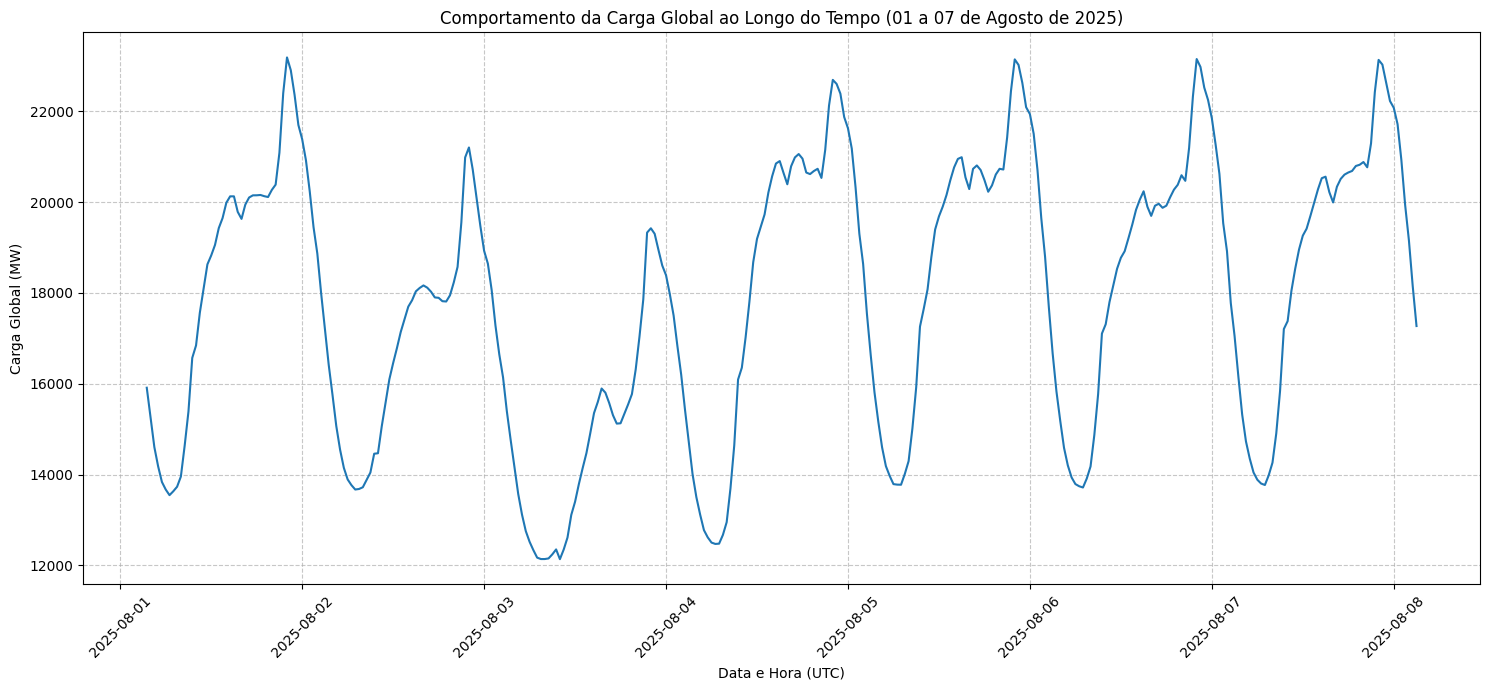

In [ ]:
# 1. Converter 'Data_Hora_UTC' para formato datetime
df['Data_Hora_UTC'] = pd.to_datetime(df['Data_Hora_UTC'])

# 2. Gráfico de linha: Comportamento da Carga Global ao longo do tempo
plt.figure(figsize=(15, 7))
sns.lineplot(x='Data_Hora_UTC', y='Carga_Global', data=df)
plt.title('Comportamento da Carga Global ao Longo do Tempo (01 a 07 de Agosto de 2025)')
plt.xlabel('Data e Hora (UTC)')
plt.ylabel('Carga Global (MW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretação do Gráfico 1: Comportamento da Carga Global ao Longo do Tempo

O gráfico de linha mostra as flutuações da carga global ao longo da semana analisada. Podemos observar um padrão diário claro, com quedas de carga durante as madrugadas e picos durante o dia, especialmente no período da tarde/noite. Há variações significativas entre os dias, indicando diferentes níveis de demanda ou influências externas ao longo da semana. É possível notar uma tendência de aumento da carga em alguns dias da semana, seguida por uma redução.

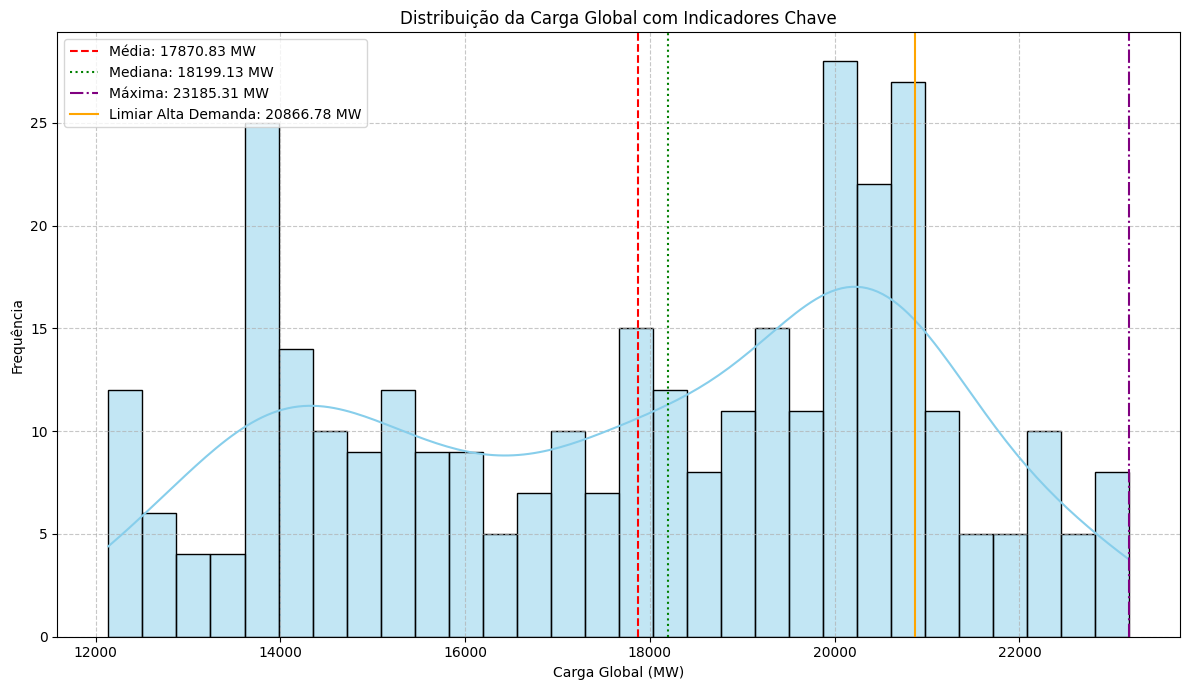

In [ ]:
# 3. Histograma: Distribuição da Carga Global com indicadores
plt.figure(figsize=(12, 7))
sns.histplot(df['Carga_Global'], bins=30, kde=True, color='skyblue')
plt.axvline(carga_media, color='red', linestyle='--', label=f'Média: {carga_media:.2f} MW')
plt.axvline(mediana_carga, color='green', linestyle=':', label=f'Mediana: {mediana_carga:.2f} MW')
plt.axvline(carga_maxima, color='purple', linestyle='-.', label=f'Máxima: {carga_maxima:.2f} MW')
plt.axvline(limiar, color='orange', linestyle='-', label=f'Limiar Alta Demanda: {limiar:.2f} MW')

plt.title('Distribuição da Carga Global com Indicadores Chave')
plt.xlabel('Carga Global (MW)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretação do Gráfico 2: Distribuição da Carga Global com Indicadores Chave

O histograma revela a frequência com que diferentes níveis de carga global foram observados. A distribuição parece bimodal ou assimétrica, com a maior parte dos registros concentrada em torno da média e da mediana. A linha vermelha (média) e verde (mediana) estão próximas, sugerindo que a distribuição não é fortemente enviesada. A linha roxa (carga máxima) e a laranja (limiar de alta demanda) estão na cauda direita da distribuição, confirmando que os períodos de carga máxima e alta demanda representam ocorrências menos frequentes, mas significativas para a análise de picos de demanda.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
# DESAFIO 7 — Síntese para o relatório

resumo_resultados = f"""
Região analisada: São Paulo (SP)

Período analisado: 01/08/2025 a 07/08/2025

Quantidade de registros: {qtd_medicoes}

Carga mínima: {carga_minima:.3f} MW
Carga máxima: {carga_maxima:.3f} MW
Carga média: {carga_media:.3f} MW
Mediana da carga: {mediana_carga:.3f} MW
Amplitude da carga: {amplitude:.3f} MW

Limiar de alta demanda (90% da carga máxima): {limiar:.3f} MW

Registros de alta demanda: {qtd_alta_demanda}
Percentual de alta demanda: {percentual_alta_demanda:.2f}%

Momento do pico:
- Data: {data_pico}
- Horário (UTC): {horario_pico_utc}

Segundo critério: Carga acima da média.
Registros acima da média: {qtd_acima_media}
Percentual acima da média: {percentual_acima_media:.2f}%
"""

print(resumo_resultados)


Região analisada: São Paulo (SP)

Período analisado: 01/08/2025 a 07/08/2025

Quantidade de registros: 336

Carga mínima: 12139.253 MW
Carga máxima: 23185.312 MW
Carga média: 17870.829 MW
Mediana da carga: 18199.128 MW
Amplitude da carga: 11046.059 MW

Limiar de alta demanda (90% da carga máxima): 20866.781 MW

Registros de alta demanda: 50
Percentual de alta demanda: 14.88%

Momento do pico:
- Data: 2025-08-01
- Horário (UTC): 2025-08-01T22:00:00.000Z

Segundo critério: Carga acima da média.
Registros acima da média: 184
Percentual acima da média: 54.76%



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

In [ ]:

from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)


## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
# DESAFIO 8 — Relatório técnico

relatorio = f"""
RELATÓRIO TÉCNICO – ANÁLISE DA CARGA ELÉTRICA (ONS)

Foi realizada uma análise da carga elétrica da área de carga de São Paulo (SP),
utilizando dados públicos da API do Operador Nacional do Sistema Elétrico (ONS)
referentes ao período de 01/08/2025 a 07/08/2025.

Durante o período analisado foram registradas {qtd_medicoes} medições de carga.
A carga mínima observada foi de {carga_minima:.3f} MW e a carga máxima foi de
{carga_maxima:.3f} MW, resultando em uma amplitude de {amplitude:.3f} MW.
A carga média registrada foi de {carga_media:.3f} MW, enquanto a mediana foi de
{mediana_carga:.3f} MW.

Os períodos de alta demanda, definidos como valores superiores a 90% da carga
máxima, totalizaram {qtd_alta_demanda} registros, correspondendo a
{percentual_alta_demanda:.2f}% do conjunto de dados.

Também foi aplicado um segundo critério de análise, considerando cargas acima da
média. Esse critério identificou {qtd_acima_media} registros, equivalentes a
{percentual_acima_media:.2f}% das medições, indicando que mais da metade do período
permaneceu com carga superior ao valor médio observado.

Os gráficos produzidos mostram que a carga elétrica apresenta variações ao longo
dos dias, com aumento nos horários de maior consumo e redução durante a madrugada.
A distribuição dos valores concentra-se próxima da média, enquanto os picos de
consumo representam uma parcela menor das medições.

Conclui-se que o sistema elétrico de São Paulo apresentou comportamento compatível
com um padrão diário de demanda, alternando períodos de baixa e alta carga ao longo
da semana analisada.
"""

print(relatorio)


RELATÓRIO TÉCNICO – ANÁLISE DA CARGA ELÉTRICA (ONS)

Foi realizada uma análise da carga elétrica da área de carga de São Paulo (SP),
utilizando dados públicos da API do Operador Nacional do Sistema Elétrico (ONS)
referentes ao período de 01/08/2025 a 07/08/2025.

Durante o período analisado foram registradas 336 medições de carga.
A carga mínima observada foi de 12139.253 MW e a carga máxima foi de
23185.312 MW, resultando em uma amplitude de 11046.059 MW.
A carga média registrada foi de 17870.829 MW, enquanto a mediana foi de
18199.128 MW.

Os períodos de alta demanda, definidos como valores superiores a 90% da carga
máxima, totalizaram 50 registros, correspondendo a
14.88% do conjunto de dados.

Também foi aplicado um segundo critério de análise, considerando cargas acima da
média. Esse critério identificou 184 registros, equivalentes a
54.76% das medições, indicando que mais da metade do período
permaneceu com carga superior ao valor médio observado.

Os gráficos produzidos mostram

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

### 1. Os indicadores foram utilizados corretamente?

Sim. Os indicadores apresentados no relatório estão de acordo com os cálculos realizados no notebook. Foram analisadas 336 medições, com carga mínima de 12.139,253 MW, máxima de 23.185,312 MW, média de 17.870,829 MW, mediana de 18.199,128 MW e amplitude de 11.046,059 MW. O critério de alta demanda também foi aplicado corretamente: valores superiores a 90% da carga máxima resultaram em um limiar de 20.866,781 MW, com 50 registros, equivalentes a 14,88% das medições. O segundo critério, carga acima da média, encontrou 184 registros, correspondentes a 54,76% do total.

### 2. Há alguma afirmação que não pode ser confirmada pelos dados?

Sim. A frase de que a carga apresenta aumento nos horários de maior consumo e redução durante a madrugada é compatível com o comportamento observado nos gráficos, mas deve ser entendida como uma descrição do período analisado, e não como uma regra geral para o sistema elétrico. Além disso, não é possível afirmar, somente com esses dados, quais fatores causaram os aumentos ou reduções da carga. Os dados mostram o comportamento da demanda, mas não apresentam variáveis explicativas suficientes para estabelecer causas.

### 3. Houve interpretação exagerada ou causalidade não demonstrada?

Não foram identificadas causas explícitas no texto, mas algumas conclusões poderiam ser interpretadas de forma mais ampla do que os dados permitem. A expressão “padrão diário de demanda” é adequada para descrever a alternância observada no período, porém não deve ser generalizada para outros períodos sem uma análise adicional. Também é importante diferenciar correlação temporal de causalidade: os dados permitem observar que a carga varia ao longo do dia, mas não permitem concluir que um determinado fator seja responsável por essa variação.

### 4. Que alterações a equipe realizou no texto?

Nós revisamos o texto para manter somente conclusões sustentadas pelos cálculos e pelos gráficos. Foram mantidos os principais indicadores numéricos e os percentuais calculados no notebook.

Também foram feitas as seguintes alterações:
- deixamos explícito que a análise se refere à área de carga de São Paulo e ao período de 01/08/2025 a 07/08/2025;
- mantivemos os valores de média, mediana, mínimo, máximo e amplitude;
- destacamos que os registros acima de 90% do máximo representam apenas 14,88% das medições;
- diferenciamos “carga acima da média” de “alta demanda”, pois são critérios diferentes;
- evitamos atribuir causas às variações da carga, já que elas não podem ser demonstradas pelos dados disponíveis;
- evitamos generalizar os resultados para períodos diferentes do analisado.

_Escreva aqui a versão final revisada._

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**